In [1]:
!pip install -q grad-cam pydicom nibabel
import os
import glob
import numpy as np
import pandas as pd
import pydicom
import cv2
import torch
import torch.nn as nn
import nibabel as nib
from torch.utils.data import Dataset, DataLoader # <--- Fondamentale per risolvere l'errore
from torchvision import models
from pydicom.pixel_data_handlers.util import apply_voi_lut
from sklearn.model_selection import train_test_split

# Percorsi (devono essere coerenti con il mio ambiente Kaggle)
BASE_PATH = "/kaggle/input/rsna-2022-cervical-spine-fracture-detection"
TRAIN_IMAGES_DIR = os.path.join(BASE_PATH, "train_images")
TRAIN_CSV = os.path.join(BASE_PATH, "train.csv")
SEG_DIR = os.path.join(BASE_PATH, "segmentations")

class RSNAKaggleDataset(Dataset):
    def __init__(self, df, image_dir, seg_dir=None):
        self.df = df
        self.image_dir = image_dir
        self.seg_dir = seg_dir

    def __len__(self):
        return len(self.df)

    def get_anatomical_centers(self, uid, num_slices):
        seg_path = os.path.join(self.seg_dir, f"{uid}.nii.gz")
        if self.seg_dir and os.path.exists(seg_path):
            try:
                seg_img = nib.load(seg_path)
                data = seg_img.get_fdata()
                centers = []
                for v_idx in range(1, 8):
                    z_coords = np.where(data == v_idx)[2]
                    if len(z_coords) > 0:
                        centers.append(int(np.median(z_coords)))
                    else:
                        centers.append(-1) 
                return centers
            except: pass
        return np.linspace(0, num_slices-1, 9).astype(int)[1:-1]

    def preprocess_slice(self, path):
        try:
            dicom = pydicom.dcmread(path)
            img = dicom.pixel_array
            if 'WindowCenter' in dicom:
                img = apply_voi_lut(img, dicom)
            img = img - np.min(img)
            if np.max(img) != 0: img = img / np.max(img)
            img_8bit = (img * 255).astype(np.uint8)
            clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
            img = clahe.apply(img_8bit).astype(np.float32) / 255.0
            return cv2.resize(img, (224, 224))
        except:
            return None

    def __getitem__(self, idx):
        uid = self.df.iloc[idx]['StudyInstanceUID']
        labels = self.df.iloc[idx][['C1','C2','C3','C4','C5','C6','C7']].values.astype(float)
        path = os.path.join(self.image_dir, uid)
        slices = sorted(glob.glob(os.path.join(path, "*.dcm")), 
                        key=lambda x: int(os.path.basename(x).replace('.dcm', '')))
        
        vertebrae_stacks = []
        if len(slices) >= 7:
            centers = self.get_anatomical_centers(uid, len(slices))
            for mid in centers:
                if mid == -1:
                    vertebrae_stacks.append(np.zeros((7, 224, 224)))
                    continue

                temp_stack = []
                for i in range(-3, 4):
                    idx_s = max(0, min(len(slices)-1, mid + i))
                    s = self.preprocess_slice(slices[idx_s])
                    if s is None:
                        temp_stack = [np.zeros((224, 224))] * 7
                        break
                    temp_stack.append(s)
                vertebrae_stacks.append(np.stack(temp_stack, axis=0))
        else:
            for _ in range(7): 
                vertebrae_stacks.append(np.zeros((7, 224, 224)))
                
        return torch.tensor(np.array(vertebrae_stacks), dtype=torch.float32), torch.tensor(labels, dtype=torch.float32)

print("Cella 1 pronta e librerie caricate!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 64.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Cella 1 pronta e librerie caricate!


Visualizzando: 1.2.826.0.1.3680043.4769.nii | Forma: (512, 512, 263)


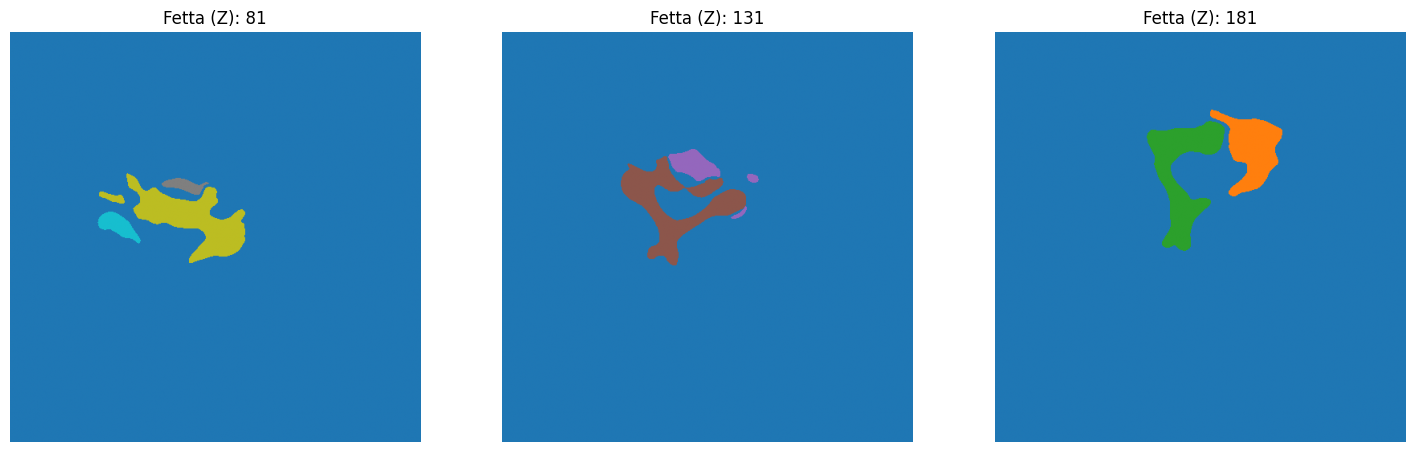

In [2]:
import nibabel as nib
import matplotlib.pyplot as plt
import random
import os
import numpy as np

def esplora_segmentazioni(seg_dir, num_esempi=1):
    # je cherche .nii ET .nii.gz pour être sûr
    seg_files = [f for f in os.listdir(seg_dir) if f.endswith(('.nii', '.nii.gz'))]
    
    if not seg_files:
        print(f"Errore: Nessun file trovato in {seg_dir}")
        return

    for _ in range(num_esempi):
        file_scelto = random.choice(seg_files)
        path_completo = os.path.join(seg_dir, file_scelto)
        
        img = nib.load(path_completo)
        data = img.get_fdata()
        
        # Correction d'orientation fréquente pour NIfTI sur Kaggle
        data = np.transpose(data, (1, 0, 2))
        data = np.flip(data, axis=0)

        print(f"Visualizzando: {file_scelto} | Forma: {data.shape}")
        
        z_mid = data.shape[2] // 2
        fette = [max(0, z_mid - 50), z_mid, min(data.shape[2]-1, z_mid + 50)]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        for i, f in enumerate(fette):
            slice_data = data[:, :, f]
            # On utilise 'tab10' pour bien voir les 7 vertèbres (couleurs distinctes)
            im = axes[i].imshow(slice_data, cmap='tab10', vmin=0, vmax=7)
            axes[i].set_title(f"Fetta (Z): {f}")
            axes[i].axis('off')
        
        plt.show()

#  SEG_DIR  doit etre bien défini
SEG_DIR = os.path.join(BASE_PATH, "segmentations")
esplora_segmentazioni(SEG_DIR, num_esempi=1)

In [3]:
class MultiVertebraModel(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet18(weights='DEFAULT')
        
        # MODIFICA: La rete ora accetta 7 canali in ingresso
        base.conv1 = nn.Conv2d(7, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        self.encoder = nn.Sequential(*list(base.children())[:-1])
        self.fc = nn.Linear(512, 1)

    def forward(self, x):
        if x.dim() == 4:
            x = x.unsqueeze(1)
        bs, nv, c, h, w = x.shape
        x = x.view(bs * nv, c, h, w) 
        features = self.encoder(x).view(bs * nv, -1)
        out = self.fc(features)
        return out.view(bs, nv)

print("Cella 2 fatta (Modello aggiornato a 7 fette)")

Cella 2 fatta (Modello aggiornato a 7 fette)


In [4]:
def run_training():
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    df = pd.read_csv(TRAIN_CSV)
    
    # Sélection des données 
    seg_ids = [f.replace('.nii.gz', '') for f in os.listdir(SEG_DIR)]
    df_with_seg = df[df['StudyInstanceUID'].isin(seg_ids)]
    df_others = df[~df['StudyInstanceUID'].isin(seg_ids)].sample(n=200, random_state=42)
    
    df_final = pd.concat([df_with_seg, df_others]).sample(frac=1).reset_index(drop=True)
    train_df, val_df = train_test_split(df_final, test_size=0.15, random_state=42)

    train_loader = DataLoader(RSNAKaggleDataset(train_df, TRAIN_IMAGES_DIR, SEG_DIR), batch_size=4, shuffle=True)
    val_loader = DataLoader(RSNAKaggleDataset(val_df, TRAIN_IMAGES_DIR, SEG_DIR), batch_size=4)

    model = MultiVertebraModel().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0]).to(DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    print(f"Training avviato su {len(df_final)} pazienti totali.")
    
    num_epochs =  15
    for epoch in range(num_epochs): 
        # --- PHASE D'ENTRAÎNEMENT ---
        model.train()
        epoch_loss = 0
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            if i % 20 == 0:
                print(f"Epoca [{epoch+1}/{num_epochs}] | Batch {i}/{len(train_loader)} | Loss Train: {loss.item():.4f}")
        
        # --- PHASE DE VALIDATION (nouveau bloc) ---
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for v_images, v_labels in val_loader:
                v_images, v_labels = v_images.to(DEVICE), v_labels.to(DEVICE)
                v_outputs = model(v_images)
                v_loss = criterion(v_outputs, v_labels)
                val_loss += v_loss.item()
                
                # Calcul de l'accuracy (seuil à 0.5)
                preds = (torch.sigmoid(v_outputs) > 0.5).float()
                correct += (preds == v_labels).sum().item()
                total += v_labels.numel()

        avg_train_loss = epoch_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        accuracy = correct / total
        
        print(f"\n--- FINE EPOCA {epoch+1} ---")
        print(f"Loss Media Train: {avg_train_loss:.4f}")
        print(f"Loss Media Val: {avg_val_loss:.4f}")
        print(f"Accuracy Validation: {accuracy:.4f}\n")

    torch.save(model.state_dict(), "/kaggle/working/cervical_model_v7_slices.pth")
    return model, val_df

# Esecuzione
model, val_df = run_training()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]


Training avviato su 200 pazienti totali.
Epoca [1/15] | Batch 0/43 | Loss Train: 0.4452
Epoca [1/15] | Batch 20/43 | Loss Train: 0.3819
Epoca [1/15] | Batch 40/43 | Loss Train: 1.3006

--- FINE EPOCA 1 ---
Loss Media Train: 0.5593
Loss Media Val: 0.7693
Accuracy Validation: 0.8905

Epoca [2/15] | Batch 0/43 | Loss Train: 0.4684
Epoca [2/15] | Batch 20/43 | Loss Train: 0.4942
Epoca [2/15] | Batch 40/43 | Loss Train: 0.3340

--- FINE EPOCA 2 ---
Loss Media Train: 0.4824
Loss Media Val: 0.6924
Accuracy Validation: 0.8905

Epoca [3/15] | Batch 0/43 | Loss Train: 0.4482
Epoca [3/15] | Batch 20/43 | Loss Train: 0.2414
Epoca [3/15] | Batch 40/43 | Loss Train: 0.7299

--- FINE EPOCA 3 ---
Loss Media Train: 0.3935
Loss Media Val: 0.6874
Accuracy Validation: 0.8905

Epoca [4/15] | Batch 0/43 | Loss Train: 0.3334
Epoca [4/15] | Batch 20/43 | Loss Train: 0.2462
Epoca [4/15] | Batch 40/43 | Loss Train: 0.3957

--- FINE EPOCA 4 ---
Loss Media Train: 0.3222
Loss Media Val: 0.9730
Accuracy Validation:

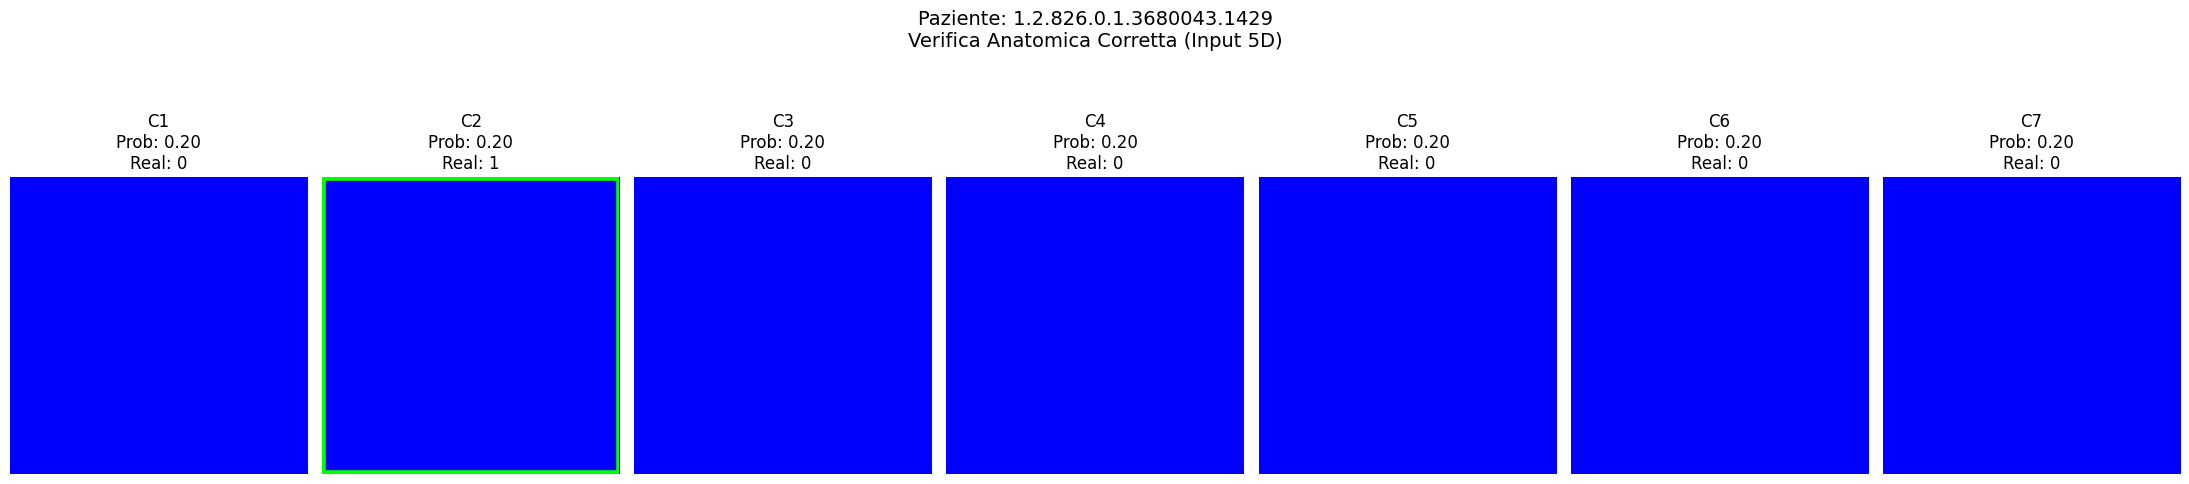

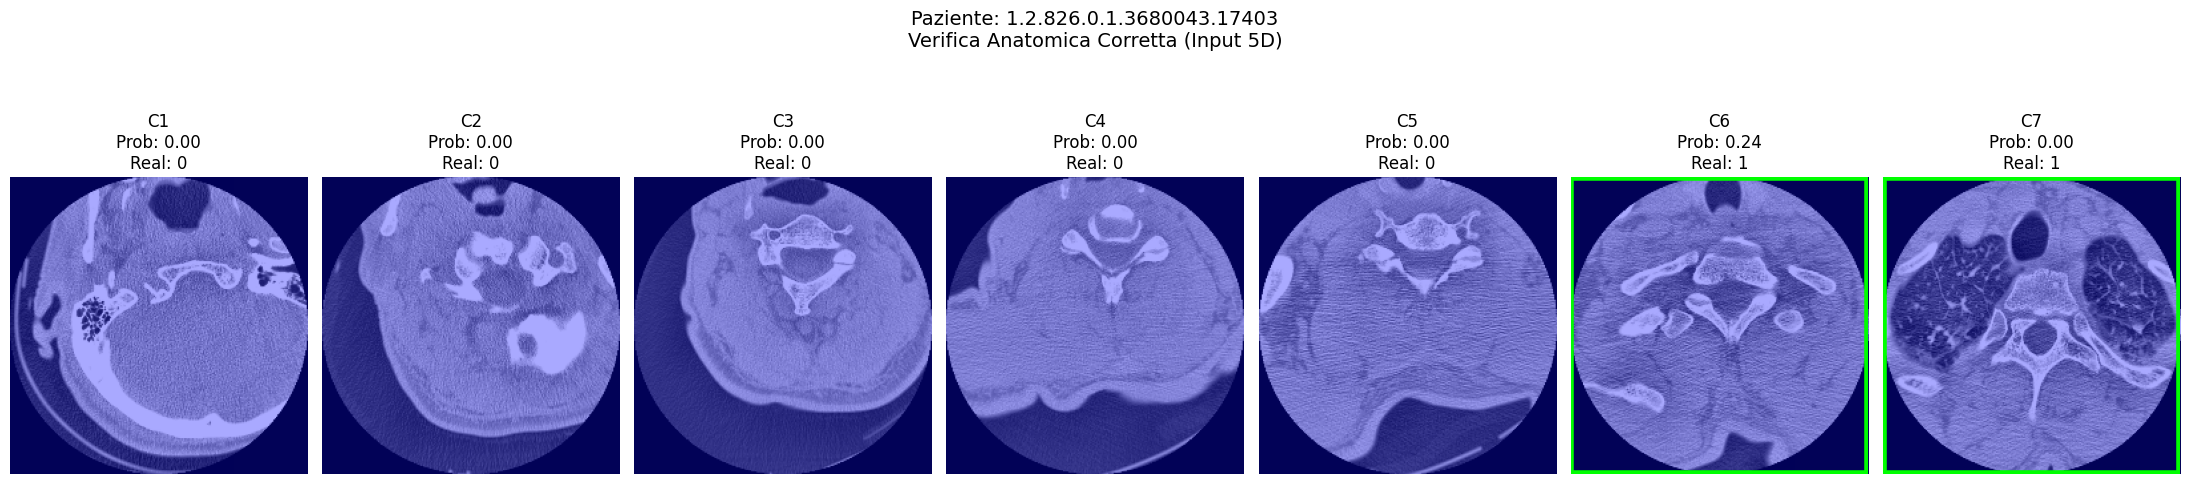

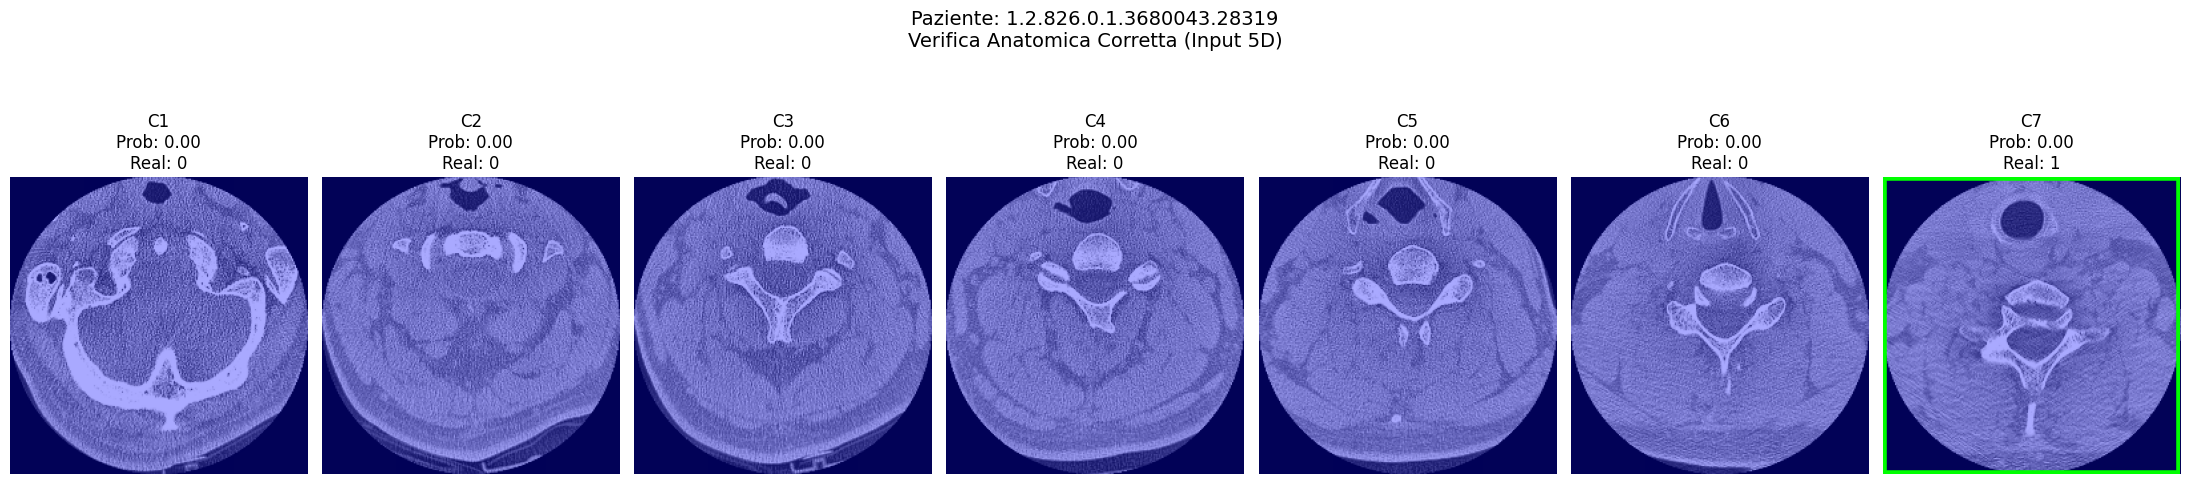

In [5]:

import sys
# Questo forza Python a cercare le nuove librerie installate
!pip install -q grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import numpy as np
import cv2
# Visualizzazione
def visualizza_predizioni(model, dataset, num_esempi=3):
    model.eval()
    device = next(model.parameters()).device
    target_layers = [model.encoder[-1]]
    cam = GradCAM(model=model, target_layers=target_layers)

    for _ in range(num_esempi):
        idx = np.random.randint(0, len(dataset))
        inputs, labels = dataset[idx] # inputs: (7, 7, 224, 224)
        uid = dataset.df.iloc[idx]['StudyInstanceUID']
        
        fig, axes = plt.subplots(1, 7, figsize=(22, 6))
        fig.suptitle(f"Paziente: {uid}\nVerifica Anatomica Corretta (Input 5D)", fontsize=14)

        for v_idx in range(7):
            # Preparo il tensor a 5D: (Batch, Vertebra, Canali, H, W)
            # Passo l'intero stack al modello
            input_stack_5d = inputs.unsqueeze(0).to(device) # Shape: (1, 7, 7, 224, 224)
            
            with torch.no_grad():
                outputs = model(input_stack_5d)
                prob = torch.sigmoid(outputs[0, v_idx]).item() # Estraiamo probabilità della vertebra specifica

            # Grad-CAM specifica sulla vertebra v_idx
            # Devo creare un tensor specifico per la vertebra corrente per la CAM
            vertebra_input_cam = inputs[v_idx].unsqueeze(0).to(device) # Shape: (1, 7, 224, 224)
            
            grayscale_cam = cam(input_tensor=vertebra_input_cam, targets=[ClassifierOutputTarget(0)])[0, :]
            
            # Visualizzo sulla fetta centrale (indice 3)
            img_base = inputs[v_idx, 3].numpy() 
            img_rgb = cv2.cvtColor((img_base * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB).astype(np.float32) / 255.0
            cam_image = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)
            
            axes[v_idx].imshow(cam_image)
            title_color = 'red' if prob > 0.5 else 'black'
            axes[v_idx].set_title(f"C{v_idx+1}\nProb: {prob:.2f}\nReal: {int(labels[v_idx])}", color=title_color)
            axes[v_idx].axis('off')
            
            if labels[v_idx] == 1:
                rect = plt.Rectangle((0,0), 223, 223, linewidth=4, edgecolor='lime', facecolor='none')
                axes[v_idx].add_patch(rect)
        
        plt.tight_layout()
        plt.show()

# Esecuzione
model.to("cuda" if torch.cuda.is_available() else "cpu")
val_dataset_small = RSNAKaggleDataset(val_df.head(10), TRAIN_IMAGES_DIR, SEG_DIR)
visualizza_predizioni(model, val_dataset_small, num_esempi=3)